In [ ]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import TimeSeriesSplit

# Generar datos de ejemplo
# Supongamos que tenemos dos clases de series temporales
# Clase 1: Senos
# Clase 2: Cosenos
n_samples = 100
n_timepoints = 50

# Crear series temporales de senos y cosenos
X_sin = np.array([np.sin(np.linspace(0, 4 * np.pi, n_timepoints)) + np.random.normal(0, 0.1, n_timepoints) for _ in range(n_samples)])
X_cos = np.array([np.cos(np.linspace(0, 4 * np.pi, n_timepoints)) + np.random.normal(0, 0.1, n_timepoints) for _ in range(n_samples)])

# Etiquetas
y_sin = np.zeros(n_samples)  # Clase 0
y_cos = np.ones(n_samples)   # Clase 1

# Combinar las series y etiquetas
X = np.vstack((X_sin, X_cos))
y = np.hstack((y_sin, y_cos))

# Configurar TimeSeriesSplit
n_splits = 10
tscv = TimeSeriesSplit(n_splits=n_splits)

# Crear el modelo KNN
k = 3  # Número de vecinos
knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')

# Evaluar el modelo usando TimeSeriesSplit
accuracies = []

for train_index, test_index in tscv.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Entrenar el modelo
    knn.fit(X_train, y_train)

    # Predecir las etiquetas para el conjunto de prueba
    y_pred = knn.predict(X_test)

    # Evaluar la precisión
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)
    print(f'Precisión en este split: {accuracy:.2f}')

# Mostrar la precisión promedio
print(f'Precisión promedio en {n_splits} splits: {np.mean(accuracies):.2f}')

# Ejemplo de predicción para una nueva serie temporal
new_series = np.sin(np.linspace(0, 4 * np.pi, n_timepoints)) + np.random.normal(0, 0.1, n_timepoints)
predicted_class = knn.predict([new_series])
print(f'Clase predicha para la nueva serie temporal: {predicted_class[0]}')

Precisión en este split: 1.00
Precisión en este split: 1.00
Precisión en este split: 1.00
Precisión en este split: 1.00
Precisión en este split: 0.44
Precisión en este split: 1.00
Precisión en este split: 1.00
Precisión en este split: 1.00
Precisión en este split: 1.00
Precisión en este split: 1.00
Precisión promedio en 10 splits: 0.94
Clase predicha para la nueva serie temporal: 0.0


In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score

# Generar datos de ejemplo
n_samples = 1000
n_timepoints = 50

# Crear series temporales de senos y cosenos
X_sin = np.array([np.sin(np.linspace(0, 4 * np.pi, n_timepoints)) + np.random.normal(0, 0.1, n_timepoints) for _ in range(n_samples)])
X_cos = np.array([np.cos(np.linspace(0, 4 * np.pi, n_timepoints)) + np.random.normal(0, 0.1, n_timepoints) for _ in range(n_samples)])

# Etiquetas
y_sin = np.zeros(n_samples)  # Clase 0
y_cos = np.ones(n_samples)   # Clase 1

# Combinar las series y etiquetas
X = np.vstack((X_sin, X_cos))
y = np.hstack((y_sin, y_cos))

# Parámetros para los intervalos
n_intervals = 10  # Número de intervalos en los que se dividirá cada serie temporal
interval_size = n_timepoints // n_intervals

# Crear las nuevas características basadas en intervalos
def create_interval_features(X, n_intervals):
    n_samples, n_timepoints = X.shape
    interval_features = np.zeros((n_samples, n_intervals * 3))  # Promedio, máximo y mínimo en cada intervalo

    for i in range(n_intervals):
        start = i * interval_size
        end = start + interval_size
        interval_data = X[:, start:end]

        # Calcular estadísticas para cada intervalo
        interval_features[:, i * 3] = interval_data.mean(axis=1)  # Promedio
        interval_features[:, i * 3 + 1] = interval_data.max(axis=1)  # Máximo
        interval_features[:, i * 3 + 2] = interval_data.min(axis=1)  # Mínimo

    return interval_features

X_intervals = create_interval_features(X, n_intervals)

# Configurar TimeSeriesSplit
n_splits = 10
tscv = TimeSeriesSplit(n_splits=n_splits)

# Crear el modelo RandomForest (similar a Time Series Forest)
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Evaluar el modelo usando TimeSeriesSplit
accuracies = []

for train_index, test_index in tscv.split(X_intervals):
    X_train, X_test = X_intervals[train_index], X_intervals[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Entrenar el modelo
    rf.fit(X_train, y_train)

    # Predecir las etiquetas para el conjunto de prueba
    y_pred = rf.predict(X_test)

    # Evaluar la precisión
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)
    print(f'Precisión en este split: {accuracy:.2f}')

# Mostrar la precisión promedio
print(f'Precisión promedio en {n_splits} splits: {np.mean(accuracies):.2f}')

# Ejemplo de predicción para una nueva serie temporal
new_series = np.sin(np.linspace(0, 4 * np.pi, n_timepoints)) + np.random.normal(0, 0.1, n_timepoints)
new_series_intervals = create_interval_features(np.array([new_series]), n_intervals)
predicted_class = rf.predict(new_series_intervals)
print(f'Clase predicha para la nueva serie temporal: {predicted_class[0]}')

Precisión en este split: 1.00
Precisión en este split: 1.00
Precisión en este split: 1.00
Precisión en este split: 1.00
Precisión en este split: 0.48
Precisión en este split: 1.00
Precisión en este split: 1.00
Precisión en este split: 1.00
Precisión en este split: 1.00
Precisión en este split: 1.00
Precisión promedio en 10 splits: 0.95
Clase predicha para la nueva serie temporal: 0.0


In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score

# Generar datos de ejemplo
n_samples = 100
n_timepoints = 50

# Crear series temporales de senos y cosenos
X_sin = np.array([np.sin(np.linspace(0, 4 * np.pi, n_timepoints)) + np.random.normal(0, 0.1, n_timepoints) for _ in range(n_samples)])
X_cos = np.array([np.cos(np.linspace(0, 4 * np.pi, n_timepoints)) + np.random.normal(0, 0.1, n_timepoints) for _ in range(n_samples)])

# Etiquetas
y_sin = np.zeros(n_samples)  # Clase 0
y_cos = np.ones(n_samples)   # Clase 1

# Combinar las series y etiquetas
X = np.vstack((X_sin, X_cos))
y = np.hstack((y_sin, y_cos))

# Parámetros para los intervalos
n_intervals = 5  # Número de intervalos en los que se dividirá cada serie temporal
interval_size = n_timepoints // n_intervals

# Crear las nuevas características basadas en intervalos
def create_interval_features(X, n_intervals):
    n_samples, n_timepoints = X.shape
    interval_features = np.zeros((n_samples, n_intervals * 3))  # Promedio, máximo y mínimo en cada intervalo

    for i in range(n_intervals):
        start = i * interval_size
        end = start + interval_size
        interval_data = X[:, start:end]

        # Calcular estadísticas para cada intervalo
        interval_features[:, i * 3] = interval_data.mean(axis=1)  # Promedio
        interval_features[:, i * 3 + 1] = interval_data.max(axis=1)  # Máximo
        interval_features[:, i * 3 + 2] = interval_data.min(axis=1)  # Mínimo

    return interval_features

X_intervals = create_interval_features(X, n_intervals)

# Configurar TimeSeriesSplit
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

# Lista para almacenar los modelos RF entrenados en cada split
rf_models = []

# Evaluar el modelo usando TimeSeriesSplit
accuracies = []

for train_index, test_index in tscv.split(X_intervals):
    X_train, X_test = X_intervals[train_index], X_intervals[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Crear un nuevo modelo RandomForest para cada split
    rf = RandomForestClassifier(n_estimators=100, random_state=42)

    # Entrenar el modelo
    rf.fit(X_train, y_train)

    # Guardar el modelo entrenado
    rf_models.append(rf)

    # Predecir las etiquetas para el conjunto de prueba
    y_pred = rf.predict(X_test)

    # Evaluar la precisión
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)
    print(f'Precisión en este split: {accuracy:.2f}')

# Mostrar la precisión promedio
print(f'Precisión promedio en {n_splits} splits: {np.mean(accuracies):.2f}')

# Ejemplo de predicción para una nueva serie temporal utilizando el último modelo RF entrenado
new_series = np.sin(np.linspace(0, 4 * np.pi, n_timepoints)) + np.random.normal(0, 0.1, n_timepoints)
new_series_intervals = create_interval_features(np.array([new_series]), n_intervals)
predicted_class = rf_models[-1].predict(new_series_intervals)
print(f'Clase predicha para la nueva serie temporal: {predicted_class[0]}')

Precisión en este split: 1.00
Precisión en este split: 0.97
Precisión en este split: 1.00
Precisión en este split: 1.00
Precisión en este split: 1.00
Precisión promedio en 5 splits: 0.99
Clase predicha para la nueva serie temporal: 0.0


In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score
from scipy.stats import mode

# Generar datos de ejemplo
n_samples = 100
n_timepoints = 50

# Crear series temporales de senos y cosenos
X_sin = np.array([np.sin(np.linspace(0, 4 * np.pi, n_timepoints)) + np.random.normal(0, 0.1, n_timepoints) for _ in range(n_samples)])
X_cos = np.array([np.cos(np.linspace(0, 4 * np.pi, n_timepoints)) + np.random.normal(0, 0.1, n_timepoints) for _ in range(n_samples)])

# Etiquetas
y_sin = np.zeros(n_samples)  # Clase 0
y_cos = np.ones(n_samples)   # Clase 1

# Combinar las series y etiquetas
X = np.vstack((X_sin, X_cos))
y = np.hstack((y_sin, y_cos))

# Parámetros para los intervalos
n_intervals = 5  # Número de intervalos en los que se dividirá cada serie temporal
interval_size = n_timepoints // n_intervals

# Crear las nuevas características basadas en intervalos
def create_interval_features(X, n_intervals):
    n_samples, n_timepoints = X.shape
    interval_features = np.zeros((n_samples, n_intervals * 3))  # Promedio, máximo y mínimo en cada intervalo

    for i in range(n_intervals):
        start = i * interval_size
        end = start + interval_size
        interval_data = X[:, start:end]

        # Calcular estadísticas para cada intervalo
        interval_features[:, i * 3] = interval_data.mean(axis=1)  # Promedio
        interval_features[:, i * 3 + 1] = interval_data.max(axis=1)  # Máximo
        interval_features[:, i * 3 + 2] = interval_data.min(axis=1)  # Mínimo

    return interval_features

X_intervals = create_interval_features(X, n_intervals)

# Configurar TimeSeriesSplit
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

# Lista para almacenar los modelos RF entrenados en cada split
rf_models = []

# Evaluar el modelo usando TimeSeriesSplit
accuracies = []

for train_index, test_index in tscv.split(X_intervals):
    X_train, X_test = X_intervals[train_index], X_intervals[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Crear un nuevo modelo RandomForest para cada split
    rf = RandomForestClassifier(n_estimators=100, random_state=42)

    # Entrenar el modelo
    rf.fit(X_train, y_train)

    # Guardar el modelo entrenado
    rf_models.append(rf)

    # Predecir las etiquetas para el conjunto de prueba
    y_pred = rf.predict(X_test)

    # Evaluar la precisión
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)
    print(f'Precisión en este split: {accuracy:.2f}')

# Mostrar la precisión promedio
print(f'Precisión promedio en {n_splits} splits: {np.mean(accuracies):.2f}')

# Función para predecir utilizando votación de todos los modelos en rf_models
def predict_with_voting(models, X):
    predictions = np.array([model.predict(X) for model in models])
    majority_vote = mode(predictions, axis=0)[0]  # Votación por mayoría
    return majority_vote.ravel()

# Ejemplo de predicción para una nueva serie temporal
new_series = np.sin(np.linspace(0, 4 * np.pi, n_timepoints)) + np.random.normal(0, 0.1, n_timepoints)
new_series_intervals = create_interval_features(np.array([new_series]), n_intervals)

# Predicción utilizando la votación de todos los modelos
predicted_class_voting = predict_with_voting(rf_models, new_series_intervals)
print(f'Clase predicha para la nueva serie temporal (votación): {predicted_class_voting[0]}')

Precisión en este split: 1.00
Precisión en este split: 0.97
Precisión en este split: 1.00
Precisión en este split: 1.00
Precisión en este split: 1.00
Precisión promedio en 5 splits: 0.99
Clase predicha para la nueva serie temporal (votación): 0.0


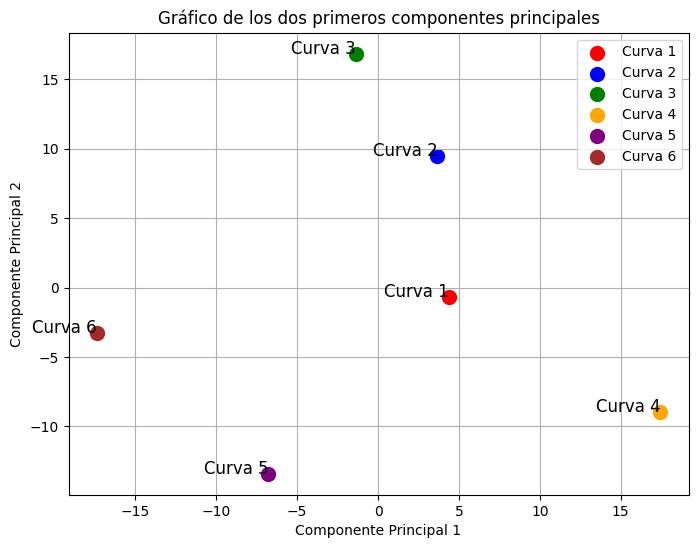

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Supongamos que tus curvas están en una matriz de numpy llamada X de tamaño 6x500
X = np.random.rand(6, 500)  # Sustituir con tus datos

# Estandarizar los datos
scaler = StandardScaler()
X_estandarizado = scaler.fit_transform(X)

# Aplicar PCA
pca = PCA(n_components=2)  # Seleccionar los dos primeros componentes principales
X_pca = pca.fit_transform(X_estandarizado)

# Definir una lista de colores para cada curva
colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown']

# Graficar los dos primeros componentes principales
plt.figure(figsize=(8, 6))
for i in range(X_pca.shape[0]):
    plt.scatter(X_pca[i, 0], X_pca[i, 1], color=colors[i], label=f'Curva {i+1}', s=100)
    plt.text(X_pca[i, 0], X_pca[i, 1], f'Curva {i+1}', fontsize=12, ha='right')

plt.title('Gráfico de los dos primeros componentes principales')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.grid(True)

# Evitar duplicados en la leyenda
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

plt.show()

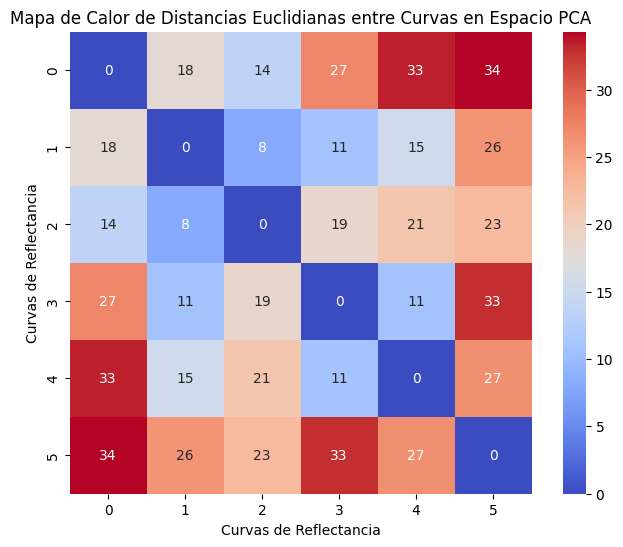

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist, squareform

# Supongamos que tus curvas están en una matriz de numpy llamada X de tamaño 6x500
X = np.random.rand(6, 500)  # Sustituir con tus datos

# Estandarizar los datos
scaler = StandardScaler()
X_estandarizado = scaler.fit_transform(X)

# Aplicar PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_estandarizado)

# Calcular la matriz de distancias euclidianas entre cada par de curvas en el espacio PCA
dist_matrix = squareform(pdist(X_pca, metric='euclidean'))

# Crear un mapa de calor para visualizar las distancias
plt.figure(figsize=(8, 6))
sns.heatmap(dist_matrix, annot=True, cmap='coolwarm', square=True)
plt.title('Mapa de Calor de Distancias Euclidianas entre Curvas en Espacio PCA')
plt.xlabel('Curvas de Reflectancia')
plt.ylabel('Curvas de Reflectancia')
plt.show()

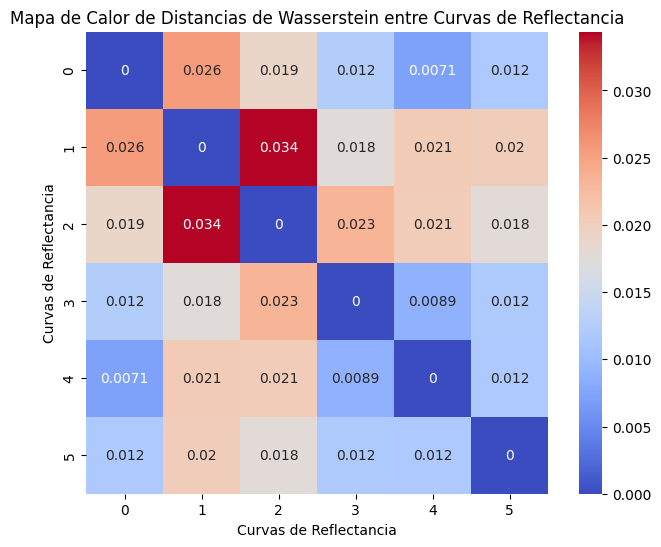

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wasserstein_distance
from scipy.spatial.distance import squareform

# Supongamos que tus curvas están en una matriz de numpy llamada X de tamaño 6x500
X = np.random.rand(6, 500)  # Sustituir con tus datos

# Calcular la matriz de distancias de Wasserstein entre cada par de curvas
n_curvas = X.shape[0]
dist_matrix = np.zeros((n_curvas, n_curvas))

for i in range(n_curvas):
    for j in range(i + 1, n_curvas):
        dist = wasserstein_distance(X[i], X[j])
        dist_matrix[i, j] = dist
        dist_matrix[j, i] = dist

# Crear un mapa de calor para visualizar las distancias de Wasserstein
plt.figure(figsize=(8, 6))
sns.heatmap(dist_matrix, annot=True, cmap='coolwarm', square=True)
plt.title('Mapa de Calor de Distancias de Wasserstein entre Curvas de Reflectancia')
plt.xlabel('Curvas de Reflectancia')
plt.ylabel('Curvas de Reflectancia')
plt.show()

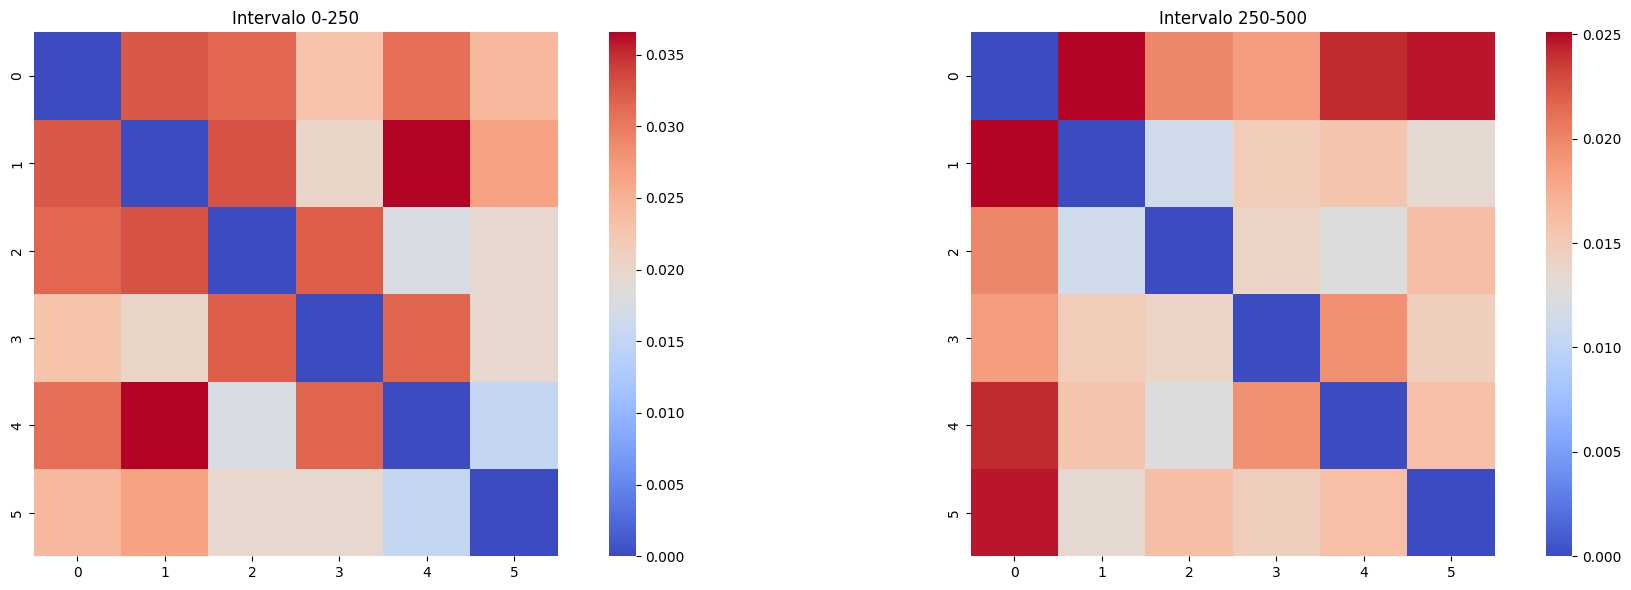

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wasserstein_distance

# Supongamos que tus curvas están en una matriz de numpy llamada X de tamaño 6x500
X = np.random.rand(6, 500)  # Sustituir con tus datos

# Definir el tamaño de los intervalos
intervalo = 250
num_intervalos = X.shape[1] // intervalo

# Crear una figura para los mapas de calor
fig, axes = plt.subplots(1, num_intervalos, figsize=(20, 6))

# Iterar sobre cada intervalo
for k in range(num_intervalos):
    # Extraer los datos del intervalo actual
    X_interval = X[:, k*intervalo:(k+1)*intervalo]

    # Calcular la matriz de distancias de Wasserstein para el intervalo actual
    n_curvas = X_interval.shape[0]
    dist_matrix = np.zeros((n_curvas, n_curvas))

    for i in range(n_curvas):
        for j in range(i + 1, n_curvas):
            dist = wasserstein_distance(X_interval[i], X_interval[j])
            dist_matrix[i, j] = dist
            dist_matrix[j, i] = dist

    # Crear el mapa de calor para este intervalo
    sns.heatmap(dist_matrix, annot=False, cmap='coolwarm', square=True, ax=axes[k])
    axes[k].set_title(f'Intervalo {k*intervalo}-{(k+1)*intervalo}')

# Ajustar el diseño para evitar solapamientos
plt.tight_layout()
plt.show()

In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Ejemplo de datos (simulados)
# Supongamos que tienes 500 puntos de características por curva
X = np.random.rand(36, 500)  # 36 muestras (6 marcas * 6 niveles) con 500 características cada una
y_marca = np.repeat(np.arange(6), 6)  # 6 marcas
y_adulteracion = np.tile(np.arange(6), 6)  # 6 niveles de adulteración (5%, 10%, ...)

# Paso 1: Clasificación de Marca
X_train, X_test, y_marca_train, y_marca_test = train_test_split(X, y_marca, test_size=0.2, random_state=42)

marca_model = RandomForestClassifier(random_state=42)
marca_model.fit(X_train, y_marca_train)

y_marca_pred = marca_model.predict(X_test)
print(f"Accuracy de clasificación de marcas: {accuracy_score(y_marca_test, y_marca_pred):.2f}")

# Paso 2: Clasificación del Nivel de Adulteración
adulteracion_models = []
adulteracion_acc = []

for marca in range(6):
    # Filtramos los datos para la marca específica
    X_marca = X[y_marca == marca]
    y_adulteracion_marca = y_adulteracion[y_marca == marca]

    X_train, X_test, y_train, y_test = train_test_split(X_marca, y_adulteracion_marca, test_size=0.2, random_state=42)

    model = RandomForestClassifier(random_state=42)
    model.fit(X_train, y_train)
    adulteracion_models.append(model)

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    adulteracion_acc.append(acc)

    print(f"Accuracy de clasificación de adulteración para marca {marca}: {acc:.2f}")

# Ejemplo de predicción con el enfoque jerárquico
nueva_muestra = np.random.rand(1, 500)  # Nueva muestra

# Paso 1: Predecir la marca
predicted_marca = marca_model.predict(nueva_muestra)[0]
print(f"Predicción de la marca: {predicted_marca}")

# Paso 2: Predecir el nivel de adulteración dentro de la marca
predicted_adulteracion = adulteracion_models[predicted_marca].predict(nueva_muestra)[0]
print(f"Predicción del nivel de adulteración: {predicted_adulteracion}")

Accuracy de clasificación de marcas: 0.00
Accuracy de clasificación de adulteración para marca 0: 0.00
Accuracy de clasificación de adulteración para marca 1: 0.00
Accuracy de clasificación de adulteración para marca 2: 0.00
Accuracy de clasificación de adulteración para marca 3: 0.00
Accuracy de clasificación de adulteración para marca 4: 0.00
Accuracy de clasificación de adulteración para marca 5: 0.00
Predicción de la marca: 4
Predicción del nivel de adulteración: 3


In [5]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

# Simulación de datos con características más informativas
X = np.random.rand(36, 500)  # 36 muestras con 500 características
y_marca = np.repeat(np.arange(6), 6)  # 6 marcas
y_adulteracion = np.tile(np.arange(6), 6)  # 6 niveles de adulteración

# Aplicar PCA para reducción de dimensionalidad
pca = PCA(n_components=6)  # Reducir a 50 componentes
X_pca = pca.fit_transform(X)

# Paso 1: Clasificación de Marca
X_train, X_test, y_marca_train, y_marca_test = train_test_split(X_pca, y_marca, test_size=0.2, random_state=42)

marca_model = RandomForestClassifier(random_state=42)
marca_model.fit(X_train, y_marca_train)

y_marca_pred = marca_model.predict(X_test)
print(f"Accuracy de clasificación de marcas: {accuracy_score(y_marca_test, y_marca_pred):.2f}")

# Paso 2: Clasificación del Nivel de Adulteración
adulteracion_models = []
adulteracion_acc = []

for marca in range(6):
    # Filtramos los datos para la marca específica
    X_marca = X_pca[y_marca == marca]
    y_adulteracion_marca = y_adulteracion[y_marca == marca]

    X_train, X_test, y_train, y_test = train_test_split(X_marca, y_adulteracion_marca, test_size=0.2, random_state=42)

    model = RandomForestClassifier(random_state=42)
    model.fit(X_train, y_train)
    adulteracion_models.append(model)

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    adulteracion_acc.append(acc)

    print(f"Accuracy de clasificación de adulteración para marca {marca}: {acc:.2f}")

# Ejemplo de predicción con el enfoque jerárquico
nueva_muestra = np.random.rand(1, 500)  # Nueva muestra
nueva_muestra_pca = pca.transform(nueva_muestra)  # Transformar nueva muestra con PCA

# Paso 1: Predecir la marca
predicted_marca = marca_model.predict(nueva_muestra_pca)[0]
print(f"Predicción de la marca: {predicted_marca}")

# Paso 2: Predecir el nivel de adulteración dentro de la marca
predicted_adulteracion = adulteracion_models[predicted_marca].predict(nueva_muestra_pca)[0]
print(f"Predicción del nivel de adulteración: {predicted_adulteracion}")

Accuracy de clasificación de marcas: 0.12
Accuracy de clasificación de adulteración para marca 0: 0.00
Accuracy de clasificación de adulteración para marca 1: 0.00
Accuracy de clasificación de adulteración para marca 2: 0.00
Accuracy de clasificación de adulteración para marca 3: 0.00
Accuracy de clasificación de adulteración para marca 4: 0.00
Accuracy de clasificación de adulteración para marca 5: 0.00
Predicción de la marca: 3
Predicción del nivel de adulteración: 4


Accuracy de clasificación de marcas: 1.00
Accuracy de clasificación de adulteración para marca 0: 0.00
Accuracy de clasificación de adulteración para marca 1: 0.00
Accuracy de clasificación de adulteración para marca 2: 0.00
Accuracy de clasificación de adulteración para marca 3: 0.00
Accuracy de clasificación de adulteración para marca 4: 0.00
Accuracy de clasificación de adulteración para marca 5: 0.00
Predicción de la marca: 2
Predicción del nivel de adulteración: 3


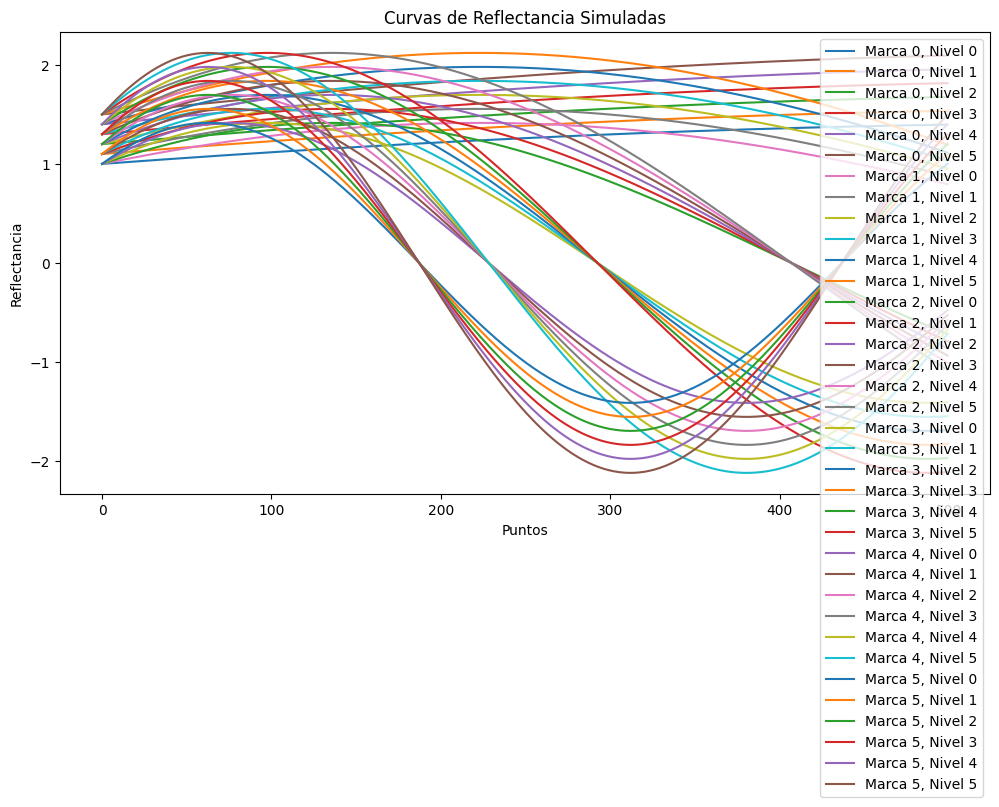

In [9]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Parámetros
num_marcas = 6
num_niveles = 6
num_puntos = 500
frecuencias = np.linspace(0.1, 1.0, num_marcas)  # Diferentes frecuencias para cada marca

# Generar datos
def generar_datos(frecuencia, nivel):
    t = np.linspace(0, 2 * np.pi, num_puntos)
    # Diferentes amplitudes para simular los niveles de adulteración
    amplitud = 1 + nivel * 0.1
    curva = amplitud * (np.sin(frecuencia * t) + np.cos(frecuencia * t))
    return curva

X = []
y_marca = []
y_adulteracion = []

for marca in range(num_marcas):
    for nivel in range(num_niveles):
        curva = generar_datos(frecuencias[marca], nivel)
        X.append(curva)
        y_marca.append(marca)
        y_adulteracion.append(nivel)

X = np.array(X)
y_marca = np.array(y_marca)
y_adulteracion = np.array(y_adulteracion)

# Aplicar PCA para reducción de dimensionalidad
pca = PCA(n_components=12)  # Reducir a 50 componentes
X_pca = pca.fit_transform(X)

# Paso 1: Clasificación de Marca
X_train, X_test, y_marca_train, y_marca_test = train_test_split(X_pca, y_marca, test_size=0.2, random_state=42)

marca_model = RandomForestClassifier(random_state=42)
marca_model.fit(X_train, y_marca_train)

y_marca_pred = marca_model.predict(X_test)
print(f"Accuracy de clasificación de marcas: {accuracy_score(y_marca_test, y_marca_pred):.2f}")

# Paso 2: Clasificación del Nivel de Adulteración
adulteracion_models = []
adulteracion_acc = []

for marca in range(num_marcas):
    # Filtramos los datos para la marca específica
    X_marca = X_pca[y_marca == marca]
    y_adulteracion_marca = y_adulteracion[y_marca == marca]

    X_train, X_test, y_train, y_test = train_test_split(X_marca, y_adulteracion_marca, test_size=0.2, random_state=42)

    model = RandomForestClassifier(random_state=42)
    model.fit(X_train, y_train)
    adulteracion_models.append(model)

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    adulteracion_acc.append(acc)

    print(f"Accuracy de clasificación de adulteración para marca {marca}: {acc:.2f}")

# Ejemplo de predicción con el enfoque jerárquico
nueva_muestra = generar_datos(frecuencias[2], 3).reshape(1, -1)  # Nueva muestra
nueva_muestra_pca = pca.transform(nueva_muestra)  # Transformar nueva muestra con PCA

# Paso 1: Predecir la marca
predicted_marca = marca_model.predict(nueva_muestra_pca)[0]
print(f"Predicción de la marca: {predicted_marca}")

# Paso 2: Predecir el nivel de adulteración dentro de la marca
predicted_adulteracion = adulteracion_models[predicted_marca].predict(nueva_muestra_pca)[0]
print(f"Predicción del nivel de adulteración: {predicted_adulteracion}")

# Opcional: Visualizar algunas curvas de datos
plt.figure(figsize=(12, 6))
for marca in range(num_marcas):
    for nivel in range(num_niveles):
        curva = generar_datos(frecuencias[marca], nivel)
        plt.plot(curva, label=f'Marca {marca}, Nivel {nivel}')
plt.title('Curvas de Reflectancia Simuladas')
plt.xlabel('Puntos')
plt.ylabel('Reflectancia')
plt.legend()
plt.show()

Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 226ms/step - accuracy: 0.4475 - loss: 1.8214 - val_accuracy: 0.1667 - val_loss: 1.6694
Epoch 2/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7141 - loss: 1.0132 - val_accuracy: 0.1667 - val_loss: 1.4181
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 165ms/step - accuracy: 0.8660 - loss: 0.6489 - val_accuracy: 0.5000 - val_loss: 1.1237
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9055 - loss: 0.5870 - val_accuracy: 0.8333 - val_loss: 0.8497
Epoch 5/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.4108 - val_accuracy: 0.6667 - val_loss: 0.7354
Epoch 6/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.3570 - val_accuracy: 0.6667 - val_loss: 0.7278
Epoch 7/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.3122 - val_accuracy: 0.6667 - val_loss: 0.6811
Epoch 8/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.2491 - val_accuracy: 0.6667 - val_loss: 0.6948
Epoch 9/10
6/

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.0000e+00 - loss: 2.1179 - val_accuracy: 0.0000e+00 - val_loss: 1.4752
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.3333 - loss: 1.7505 - val_accuracy: 0.0000e+00 - val_loss: 1.8189
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.3333 - loss: 1.4742 - val_accuracy: 0.0000e+00 - val_loss: 2.1956
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step - accuracy: 0.6667 - loss: 1.2754 - val_accuracy: 0.0000e+00 - val_loss: 2.5923
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.6667 - loss: 1.1364 - val_accuracy: 0.0000e+00 - val_loss: 2.9988
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.6667 - loss: 1.0403 - val_accuracy: 0.0000e+00 - val_loss: 3.4067
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 1.0000 - loss: 0.9728 - val_accuracy: 0.0000e+00 - val_loss: 3.8058
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 1.0000 - loss: 0.9191 - val_accuracy: 0.

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.0000e+00 - loss: 2.0672 - val_accuracy: 1.0000 - val_loss: 1.5234
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.6667 - loss: 1.6212 - val_accuracy: 0.0000e+00 - val_loss: 1.9606
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step - accuracy: 0.6667 - loss: 1.3239 - val_accuracy: 0.0000e+00 - val_loss: 2.4454
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.6667 - loss: 1.1397 - val_accuracy: 0.0000e+00 - val_loss: 2.9351
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.6667 - loss: 1.0264 - val_accuracy: 0.0000e+00 - val_loss: 3.4118
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.6667 - loss: 0.9475 - val_accuracy: 0.0000e+00 - val_loss: 3.8546
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.6667 - loss: 0.8869 - val_accuracy: 0.0000e+00 - val_loss: 4.2671
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.6667 - loss: 0.8384 - val_accuracy: 0.0000e+00

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.3333 - loss: 1.5123 - val_accuracy: 0.0000e+00 - val_loss: 2.8840
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.3333 - loss: 1.2766 - val_accuracy: 0.0000e+00 - val_loss: 3.3819
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.3333 - loss: 1.1458 - val_accuracy: 0.0000e+00 - val_loss: 3.8664
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 871ms/step - accuracy: 0.6667 - loss: 1.0557 - val_accuracy: 0.0000e+00 - val_loss: 4.3215
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 904ms/step - accuracy: 0.6667 - loss: 0.9836 - val_accuracy: 0.0000e+00 - val_loss: 4.7569
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - accuracy: 1.0000 - loss: 0.9279 - val_accuracy: 0.0000e+00 - val_loss: 5.1647
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 1.0000 - loss: 0.8832 - val_accuracy: 0.0000e+00 - val_loss: 5.5275
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 1.0000 - loss: 0.8383 - val_accuracy: 0.0000e+

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.0000e+00 - loss: 2.0318 - val_accuracy: 0.0000e+00 - val_loss: 3.0950
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.3333 - loss: 1.4398 - val_accuracy: 0.0000e+00 - val_loss: 3.5268
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 0.3333 - loss: 1.1285 - val_accuracy: 0.0000e+00 - val_loss: 4.0947
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.6667 - loss: 0.9949 - val_accuracy: 0.0000e+00 - val_loss: 4.6986
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.6667 - loss: 0.9346 - val_accuracy: 0.0000e+00 - val_loss: 5.2720
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.6667 - loss: 0.8765 - val_accuracy: 0.0000e+00 - val_loss: 5.7918
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 1.0000 - loss: 0.8235 - val_accuracy: 0.0000e+00 - val_loss: 6.2665
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.6667 - loss: 0.7874 - val_accuracy: 0.0

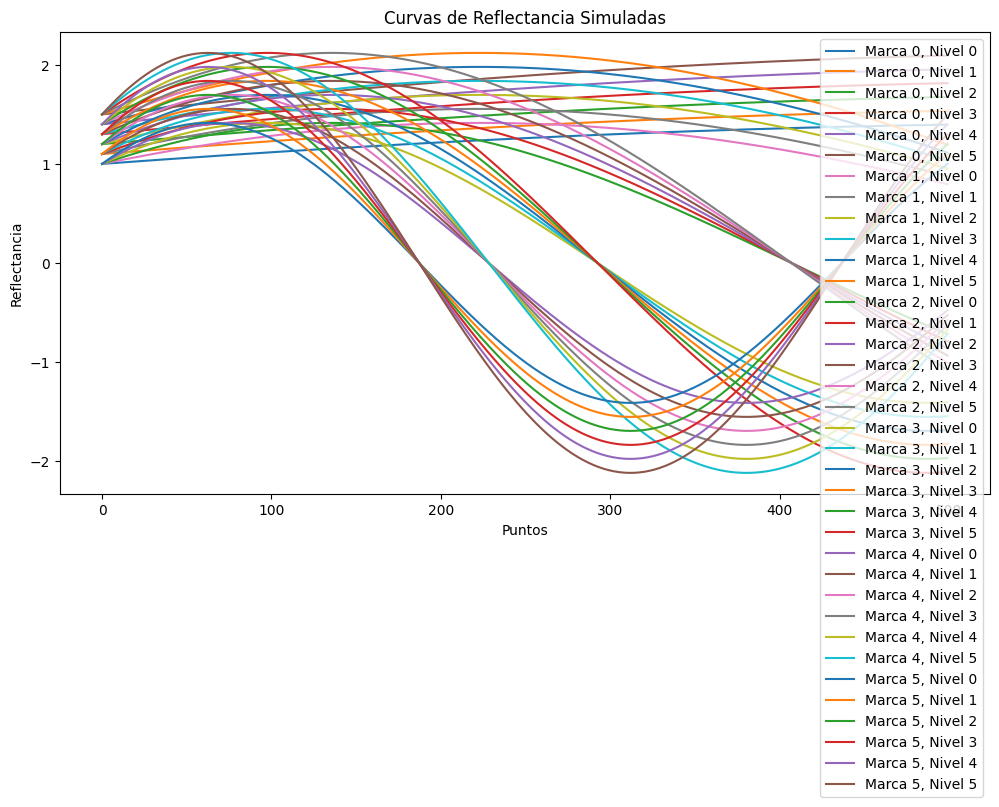

In [13]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, classification_report

# Parámetros
num_marcas = 6
num_niveles = 6
num_puntos = 500
frecuencias = np.linspace(0.1, 1.0, num_marcas)  # Diferentes frecuencias para cada marca

# Generar datos
def generar_datos(frecuencia, nivel):
    t = np.linspace(0, 2 * np.pi, num_puntos)
    # Diferentes amplitudes para simular los niveles de adulteración
    amplitud = 1 + nivel * 0.1
    curva = amplitud * (np.sin(frecuencia * t) + np.cos(frecuencia * t))
    return curva

X = []
y_marca = []
y_adulteracion = []

for marca in range(num_marcas):
    for nivel in range(num_niveles):
        curva = generar_datos(frecuencias[marca], nivel)
        X.append(curva)
        y_marca.append(marca)
        y_adulteracion.append(nivel)

X = np.array(X)
y_marca = np.array(y_marca)
y_adulteracion = np.array(y_adulteracion)

# Aplicar PCA para reducción de dimensionalidad
pca = PCA(n_components=12)  # Reducir a 12 componentes
X_pca = pca.fit_transform(X)

# Paso 1: Clasificación de Marca

# Preprocesar etiquetas
y_marca_cat = to_categorical(y_marca, num_classes=num_marcas)

# Dividir el conjunto de datos
X_train, X_test, y_marca_train, y_marca_test = train_test_split(X_pca, y_marca_cat, test_size=0.2, random_state=42)

# Redefinir la forma de los datos para la CNN
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Crear modelo CNN
marca_model = Sequential([
    Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(num_marcas, activation='softmax')
])

marca_model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
marca_model.fit(X_train, y_marca_train, epochs=10, batch_size=4, validation_split=0.2)

# Evaluar el modelo
y_marca_pred = np.argmax(marca_model.predict(X_test), axis=1)
y_marca_test_labels = np.argmax(y_marca_test, axis=1)
print(f"Accuracy de clasificación de marcas: {accuracy_score(y_marca_test_labels, y_marca_pred):.2f}")

# Paso 2: Clasificación del Nivel de Adulteración

adulteracion_models = []
adulteracion_acc = []

for marca in range(num_marcas):
    # Filtrar los datos para la marca específica
    X_marca = X_pca[y_marca == marca]
    y_adulteracion_marca = y_adulteracion[y_marca == marca]

    # Preprocesar etiquetas
    y_adulteracion_cat = to_categorical(y_adulteracion_marca, num_classes=num_niveles)

    # Dividir el conjunto de datos
    X_train, X_test, y_train, y_test = train_test_split(X_marca, y_adulteracion_cat, test_size=0.2, random_state=42)

    # Redefinir la forma de los datos para la CNN
    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
    X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

    # Crear modelo CNN
    adulteracion_model = Sequential([
        Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], 1)),
        MaxPooling1D(pool_size=2),
        Flatten(),
        Dense(512, activation='relu'),
        Dense(num_niveles, activation='softmax')
    ])

    adulteracion_model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
    adulteracion_model.fit(X_train, y_train, epochs=10, batch_size=4, validation_split=0.2)
    adulteracion_models.append(adulteracion_model)

    # Evaluar el modelo
    y_pred = np.argmax(adulteracion_model.predict(X_test), axis=1)
    y_test_labels = np.argmax(y_test, axis=1)
    acc = accuracy_score(y_test_labels, y_pred)
    adulteracion_acc.append(acc)

    print(f"Accuracy de clasificación de adulteración para marca {marca}: {acc:.2f}")

# Ejemplo de predicción con el enfoque jerárquico
nueva_muestra = generar_datos(frecuencias[2], 3).reshape(1, -1)  # Nueva muestra
nueva_muestra_pca = pca.transform(nueva_muestra)  # Transformar nueva muestra con PCA
nueva_muestra_pca = nueva_muestra_pca.reshape((nueva_muestra_pca.shape[0], nueva_muestra_pca.shape[1], 1))

# Paso 1: Predecir la marca
predicted_marca_probs = marca_model.predict(nueva_muestra_pca)
predicted_marca = np.argmax(predicted_marca_probs, axis=1)[0]
print(f"Predicción de la marca: {predicted_marca}")

# Paso 2: Predecir el nivel de adulteración dentro de la marca
predicted_adulteracion_probs = adulteracion_models[predicted_marca].predict(nueva_muestra_pca)
predicted_adulteracion = np.argmax(predicted_adulteracion_probs, axis=1)[0]
print(f"Predicción del nivel de adulteración: {predicted_adulteracion}")

# Opcional: Visualizar algunas curvas de datos
plt.figure(figsize=(12, 6))
for marca in range(num_marcas):
    for nivel in range(num_niveles):
        curva = generar_datos(frecuencias[marca], nivel)
        plt.plot(curva, label=f'Marca {marca}, Nivel {nivel}')
plt.title('Curvas de Reflectancia Simuladas')
plt.xlabel('Puntos')
plt.ylabel('Reflectancia')
plt.legend()
plt.show()

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, classification_report

# Parámetros
num_marcas = 6
num_niveles = 6
num_puntos = 500
frecuencias = np.linspace(0.1, 1.0, num_marcas)  # Diferentes frecuencias para cada marca

# Generar datos
def generar_datos(frecuencia, nivel):
    t = np.linspace(0, 2 * np.pi, num_puntos)
    # Diferentes amplitudes para simular los niveles de adulteración
    amplitud = 1 + nivel * 0.1
    curva = amplitud * (np.sin(frecuencia * t) + np.cos(frecuencia * t))
    return curva

X = []
y_marca = []
y_adulteracion = []

for marca in range(num_marcas):
    for nivel in range(num_niveles):
        curva = generar_datos(frecuencias[marca], nivel)
        X.append(curva)
        y_marca.append(marca)
        y_adulteracion.append(nivel)

X = np.array(X)
y_marca = np.array(y_marca)
y_adulteracion = np.array(y_adulteracion)

# Aplicar PCA para reducción de dimensionalidad
pca = PCA(n_components=36)  # Reducir a 12 componentes
X_pca = pca.fit_transform(X)

# Redimensionar para CNN
X_pca = X_pca.reshape((X_pca.shape[0], X_pca.shape[1], 1))

# Paso 1: Clasificación de Marca

# Preprocesar etiquetas
y_marca_cat = to_categorical(y_marca, num_classes=num_marcas)

# Dividir el conjunto de datos
X_train, X_test, y_marca_train, y_marca_test = train_test_split(X_pca, y_marca_cat, test_size=0.2, random_state=42)

# Crear modelo CNN para marcas
marca_model = Sequential([
    Conv1D(filters=16, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(16, activation='relu'),
    Dense(num_marcas, activation='softmax')
])

marca_model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
marca_model.fit(X_train, y_marca_train, epochs=15, batch_size=4, validation_split=0.2)

# Evaluar el modelo
y_marca_pred = np.argmax(marca_model.predict(X_test), axis=1)
y_marca_test_labels = np.argmax(y_marca_test, axis=1)
print(f"Accuracy de clasificación de marcas: {accuracy_score(y_marca_test_labels, y_marca_pred):.2f}")

# Paso 2: Clasificación del Nivel de Adulteración

adulteracion_models = []
adulteracion_acc = []

for marca in range(num_marcas):
    # Filtrar los datos para la marca específica
    X_marca = X_pca[y_marca == marca]
    y_adulteracion_marca = y_adulteracion[y_marca == marca]

    # Preprocesar etiquetas
    y_adulteracion_cat = to_categorical(y_adulteracion_marca, num_classes=num_niveles)

    # Dividir el conjunto de datos
    X_train, X_test, y_train, y_test = train_test_split(X_marca, y_adulteracion_cat, test_size=0.2, random_state=42)

    # Crear modelo CNN para adulteración
    adulteracion_model = Sequential([
        Conv1D(filters=16, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], 1)),
        MaxPooling1D(pool_size=2),
        Flatten(),
        Dense(8, activation='relu'),
        Dense(num_niveles, activation='softmax')
    ])

    adulteracion_model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
    adulteracion_model.fit(X_train, y_train, epochs=15, batch_size=4, validation_split=0.2)
    adulteracion_models.append(adulteracion_model)

    # Evaluar el modelo
    y_pred = np.argmax(adulteracion_model.predict(X_test), axis=1)
    y_test_labels = np.argmax(y_test, axis=1)
    acc = accuracy_score(y_test_labels, y_pred)
    adulteracion_acc.append(acc)

    print(f"Accuracy de clasificación de adulteración para marca {marca}: {acc:.2f}")

# Ejemplo de predicción con el enfoque jerárquico
nueva_muestra = generar_datos(frecuencias[2], 3).reshape(1, -1)  # Nueva muestra
nueva_muestra_pca = pca.transform(nueva_muestra)  # Transformar nueva muestra con PCA
nueva_muestra_pca = nueva_muestra_pca.reshape((nueva_muestra_pca.shape[0], nueva_muestra_pca.shape[1], 1))

# Paso 1: Predecir la marca
predicted_marca_probs = marca_model.predict(nueva_muestra_pca)
predicted_marca = np.argmax(predicted_marca_probs, axis=1)[0]
print(f"Predicción de la marca: {predicted_marca}")

# Paso 2: Predecir el nivel de adulteración dentro de la marca
predicted_adulteracion_probs = adulteracion_models[predicted_marca].predict(nueva_muestra_pca)
predicted_adulteracion = np.argmax(predicted_adulteracion_probs, axis=1)[0]
print(f"Predicción del nivel de adulteración: {predicted_adulteracion}")

# Opcional: Visualizar algunas curvas de datos
plt.figure(figsize=(12, 6))
for marca in range(num_marcas):
    for nivel in range(num_niveles):
        curva = generar_datos(frecuencias[marca], nivel)
        plt.plot(curva, label=f'Marca {marca}, Nivel {nivel}')
plt.title('Curvas de Reflectancia Simuladas')
plt.xlabel('Puntos')
plt.ylabel('Reflectancia')
plt.legend()
plt.show()

Epoch 1/15


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 106ms/step - accuracy: 0.0848 - loss: 2.1667 - val_accuracy: 0.1667 - val_loss: 2.0207
Epoch 2/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 164ms/step - accuracy: 0.2531 - loss: 1.8299 - val_accuracy: 0.1667 - val_loss: 1.9349
Epoch 3/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.2144 - loss: 1.7123 - val_accuracy: 0.1667 - val_loss: 1.8931
Epoch 4/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.1411 - loss: 1.6573 - val_accuracy: 0.1667 - val_loss: 1.8260
Epoch 5/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.2059 - loss: 1.6003 - val_accuracy: 0.1667 - val_loss: 1.7812
Epoch 6/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3813 - loss: 1.4819 - val_accuracy: 0.1667 - val_loss: 1.7477
Epoch 7/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5660 - loss: 1.4166 - val_accuracy: 0.1667 - val_loss: 1.6999
Epoch 8/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5101 - loss: 1.4236 - val_accuracy: 0.1667 - val_loss: 1.6674
Epoch 9/1

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.3333 - loss: 2.2921 - val_accuracy: 0.0000e+00 - val_loss: 2.6286
Epoch 2/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.3333 - loss: 2.2438 - val_accuracy: 0.0000e+00 - val_loss: 2.5996
Epoch 3/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.3333 - loss: 2.1979 - val_accuracy: 0.0000e+00 - val_loss: 2.5721
Epoch 4/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.3333 - loss: 2.1544 - val_accuracy: 0.0000e+00 - val_loss: 2.5462
Epoch 5/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.3333 - loss: 2.1135 - val_accuracy: 0.0000e+00 - val_loss: 2.5220
Epoch 6/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.3333 - loss: 2.0750 - val_accuracy: 0.0000e+00 - val_loss: 2.4996
Epoch 7/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.3333 - loss: 2.0390 - val_accuracy: 0.0000e+00 - val_loss: 2.4791
Epoch 8/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.3333 - loss: 2.0055 - val_accuracy: 0.0000e+00

KeyboardInterrupt: 

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - loss: 1.4245 - val_loss: 2.0520
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.3084 - val_loss: 2.0272
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.2786 - val_loss: 1.9922
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.1560 - val_loss: 1.9507
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.1252 - val_loss: 1.9010
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.0486 - val_loss: 1.8432
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.9498 - val_loss: 1.7841
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.9262 - val_loss: 1.7265
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.7916 - val_loss: 1.6728
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 289ms/step - loss: 0.8493 - val_loss: 1.6178
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.7410 - val_loss: 1.5674
Epoch 12/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.6544 - val_loss: 1.5233


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.0000e+00 - loss: 25.3853 - val_accuracy: 0.0000e+00 - val_loss: 16.7804
Epoch 2/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0000e+00 - loss: 23.4441 - val_accuracy: 0.0000e+00 - val_loss: 13.6117
Epoch 3/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0000e+00 - loss: 18.8633 - val_accuracy: 0.0000e+00 - val_loss: 10.5549
Epoch 4/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0000e+00 - loss: 15.2345 - val_accuracy: 0.0000e+00 - val_loss: 7.6155
Epoch 5/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0000e+00 - loss: 9.3681 - val_accuracy: 0.3333 - val_loss: 4.8165
Epoch 6/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.1824 - loss: 7.8490 - val_accuracy: 0.3333 - val_loss: 2.6660
Epoch 7/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2885 - loss: 4.3647 - val_accuracy: 0.8333 - val_loss: 1.9685
Epoch 8/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5696 - loss: 4.3417 - val_accuracy

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.3333 - loss: 14.6553 - val_accuracy: 0.0000e+00 - val_loss: 35.9009
Epoch 2/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.3333 - loss: 14.0953 - val_accuracy: 0.0000e+00 - val_loss: 35.4515
Epoch 3/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - accuracy: 0.3333 - loss: 13.6868 - val_accuracy: 0.0000e+00 - val_loss: 34.9542
Epoch 4/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.3333 - loss: 13.3467 - val_accuracy: 0.0000e+00 - val_loss: 34.3552
Epoch 5/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.3333 - loss: 12.9834 - val_accuracy: 0.0000e+00 - val_loss: 33.6908
Epoch 6/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.3333 - loss: 12.5907 - val_accuracy: 0.0000e+00 - val_loss: 32.9929
Epoch 7/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.3333 - loss: 12.1824 - val_accuracy: 0.0000e+00 - val_loss: 32.2829
Epoch 8/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.3333 - loss: 11.7719 - val_accur

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.3333 - loss: 17.0252 - val_accuracy: 0.0000e+00 - val_loss: 8.8837
Epoch 2/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.3333 - loss: 16.1326 - val_accuracy: 0.0000e+00 - val_loss: 8.3311
Epoch 3/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - accuracy: 0.3333 - loss: 15.2431 - val_accuracy: 0.0000e+00 - val_loss: 7.7730
Epoch 4/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.3333 - loss: 14.3568 - val_accuracy: 0.0000e+00 - val_loss: 7.2089
Epoch 5/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.3333 - loss: 13.4739 - val_accuracy: 0.0000e+00 - val_loss: 6.6394
Epoch 6/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.3333 - loss: 12.5944 - val_accuracy: 0.0000e+00 - val_loss: 6.0656
Epoch 7/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step - accuracy: 0.3333 - loss: 11.7187 - val_accuracy: 0.0000e+00 - val_loss: 5.4892
Epoch 8/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step - accuracy: 0.3333 - loss: 10.8470 - val_accurac

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.3333 - loss: 17.1255 - val_accuracy: 0.0000e+00 - val_loss: 14.7101
Epoch 2/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.3333 - loss: 16.4564 - val_accuracy: 0.0000e+00 - val_loss: 14.2900
Epoch 3/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.3333 - loss: 15.7878 - val_accuracy: 0.0000e+00 - val_loss: 13.8838
Epoch 4/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.3333 - loss: 15.1196 - val_accuracy: 0.0000e+00 - val_loss: 13.4863
Epoch 5/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.3333 - loss: 14.4519 - val_accuracy: 0.0000e+00 - val_loss: 13.0947
Epoch 6/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.3333 - loss: 13.7847 - val_accuracy: 0.0000e+00 - val_loss: 12.7069
Epoch 7/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.3333 - loss: 13.1179 - val_accuracy: 0.0000e+00 - val_loss: 12.3218
Epoch 8/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.3333 - loss: 12.4515 - val_accu

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.3333 - loss: 2.7746 - val_accuracy: 0.0000e+00 - val_loss: 2.9447
Epoch 2/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.3333 - loss: 2.3729 - val_accuracy: 0.0000e+00 - val_loss: 2.9553
Epoch 3/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step - accuracy: 0.3333 - loss: 2.0210 - val_accuracy: 0.0000e+00 - val_loss: 3.0327
Epoch 4/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.3333 - loss: 1.7417 - val_accuracy: 0.0000e+00 - val_loss: 3.1858
Epoch 5/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.3333 - loss: 1.5468 - val_accuracy: 0.0000e+00 - val_loss: 3.3938
Epoch 6/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.3333 - loss: 1.4169 - val_accuracy: 0.0000e+00 - val_loss: 3.6223
Epoch 7/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.3333 - loss: 1.3185 - val_accuracy: 0.0000e+00 - val_loss: 3.8553
Epoch 8/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.3333 - loss: 1.2362 - val_accuracy: 0.0000e+00

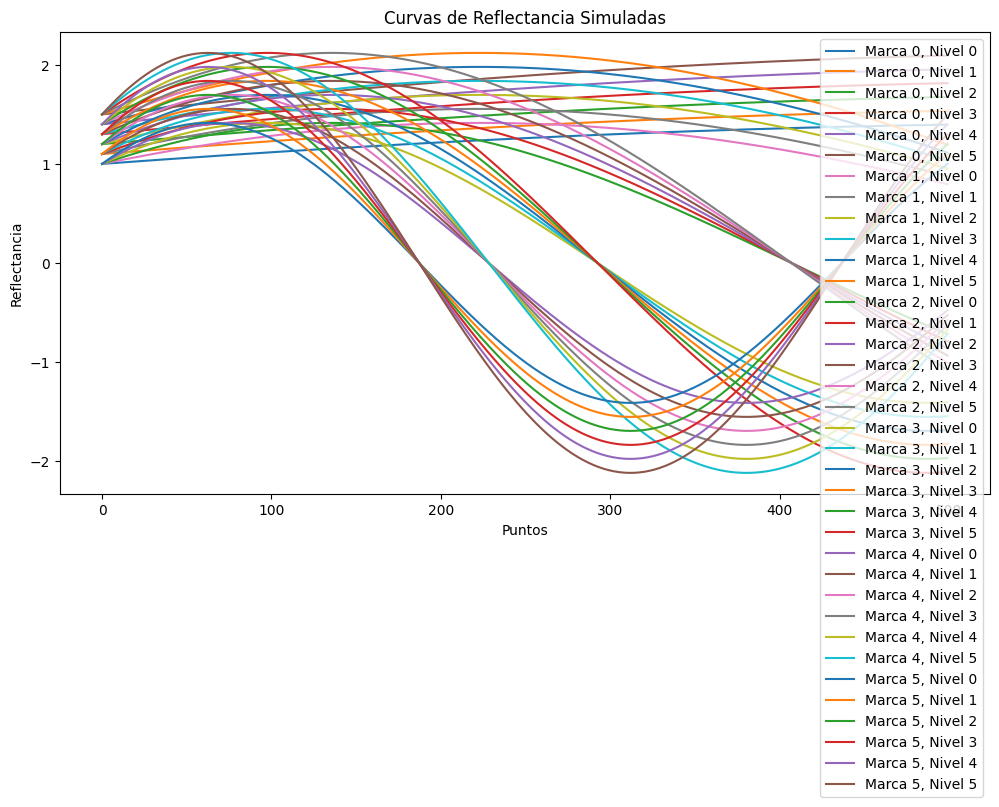

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

# Parámetros
num_marcas = 6
num_niveles = 6
num_puntos = 500
frecuencias = np.linspace(0.1, 1.0, num_marcas)  # Diferentes frecuencias para cada marca

# Generar datos
def generar_datos(frecuencia, nivel):
    t = np.linspace(0, 2 * np.pi, num_puntos)
    amplitud = 1 + nivel * 0.1
    curva = amplitud * (np.sin(frecuencia * t) + np.cos(frecuencia * t))
    return curva

X = []
y_marca = []
y_adulteracion = []

for marca in range(num_marcas):
    for nivel in range(num_niveles):
        curva = generar_datos(frecuencias[marca], nivel)
        X.append(curva)
        y_marca.append(marca)
        y_adulteracion.append(nivel)

X = np.array(X)
y_marca = np.array(y_marca)
y_adulteracion = np.array(y_adulteracion)

# Preprocesar datos
X = X.reshape((X.shape[0], X.shape[1]))  # Asegurarse de que X tenga la forma correcta para el autoencoder

# Autoencoder
input_dim = X.shape[1]
encoding_dim = 20  # Dimensión de codificación

input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='relu')(input_layer)
decoded = Dense(input_dim, activation='sigmoid')(encoded)

autoencoder = Model(inputs=input_layer, outputs=decoded)
encoder = Model(inputs=input_layer, outputs=encoded)

autoencoder.compile(optimizer=Adam(), loss='mean_squared_error')
autoencoder.fit(X, X, epochs=50, batch_size=8, validation_split=0.2)

# Codificación de datos
X_encoded = encoder.predict(X)

# Paso 1: Clasificación de Marca
X_train, X_test, y_marca_train, y_marca_test = train_test_split(X_encoded, y_marca, test_size=0.2, random_state=42)

# Crear modelo para clasificación de marcas
marca_model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(num_marcas, activation='softmax')
])

marca_model.compile(optimizer=Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
marca_model.fit(X_train, y_marca_train, epochs=15, batch_size=4, validation_split=0.2)

# Evaluar el modelo
y_marca_pred = marca_model.predict(X_test)
y_marca_pred_labels = np.argmax(y_marca_pred, axis=1)
print(f"Accuracy de clasificación de marcas: {accuracy_score(y_marca_test, y_marca_pred_labels):.2f}")

# Paso 2: Clasificación del Nivel de Adulteración

adulteracion_models = []
adulteracion_acc = []

for marca in range(num_marcas):
    # Filtrar los datos para la marca específica
    X_marca = X_encoded[y_marca == marca]
    y_adulteracion_marca = y_adulteracion[y_marca == marca]

    # Preprocesar etiquetas
    y_adulteracion_cat = to_categorical(y_adulteracion_marca, num_classes=num_niveles)

    # Dividir el conjunto de datos
    X_train, X_test, y_train, y_test = train_test_split(X_marca, y_adulteracion_cat, test_size=0.2, random_state=42)

    # Crear modelo para clasificación de adulteración
    adulteracion_model = Sequential([
        Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
        Dense(num_niveles, activation='softmax')
    ])

    adulteracion_model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
    adulteracion_model.fit(X_train, y_train, epochs=15, batch_size=4, validation_split=0.2)
    adulteracion_models.append(adulteracion_model)

    # Evaluar el modelo
    y_pred = adulteracion_model.predict(X_test)
    y_pred_labels = np.argmax(y_pred, axis=1)
    y_test_labels = np.argmax(y_test, axis=1)
    acc = accuracy_score(y_test_labels, y_pred_labels)
    adulteracion_acc.append(acc)

    print(f"Accuracy de clasificación de adulteración para marca {marca}: {acc:.2f}")

# Ejemplo de predicción con el enfoque jerárquico
nueva_muestra = generar_datos(frecuencias[2], 3).reshape(1, -1)  # Nueva muestra
nueva_muestra_encoded = encoder.predict(nueva_muestra)  # Codificar nueva muestra

# Paso 1: Predecir la marca
predicted_marca_probs = marca_model.predict(nueva_muestra_encoded)
predicted_marca = np.argmax(predicted_marca_probs, axis=1)[0]
print(f"Predicción de la marca: {predicted_marca}")

# Paso 2: Predecir el nivel de adulteración dentro de la marca
predicted_adulteracion_probs = adulteracion_models[predicted_marca].predict(nueva_muestra_encoded)
predicted_adulteracion = np.argmax(predicted_adulteracion_probs, axis=1)[0]
print(f"Predicción del nivel de adulteración: {predicted_adulteracion}")

# Opcional: Visualizar algunas curvas de datos
plt.figure(figsize=(12, 6))
for marca in range(num_marcas):
    for nivel in range(num_niveles):
        curva = generar_datos(frecuencias[marca], nivel)
        plt.plot(curva, label=f'Marca {marca}, Nivel {nivel}')
plt.title('Curvas de Reflectancia Simuladas')
plt.xlabel('Puntos')
plt.ylabel('Reflectancia')
plt.legend()
plt.show()

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, LayerNormalization, MultiHeadAttention, Add
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

# Parámetros
num_marcas = 6
num_niveles = 6
num_puntos = 500
frecuencias = np.linspace(0.1, 1.0, num_marcas)  # Diferentes frecuencias para cada marca

# Generar datos
def generar_datos(frecuencia, nivel):
    t = np.linspace(0, 2 * np.pi, num_puntos)
    amplitud = 1 + nivel * 0.1
    curva = amplitud * (np.sin(frecuencia * t) + np.cos(frecuencia * t))
    return curva

X = []
y_marca = []
y_adulteracion = []

for marca in range(num_marcas):
    for nivel in range(num_niveles):
        curva = generar_datos(frecuencias[marca], nivel)
        X.append(curva)
        y_marca.append(marca)
        y_adulteracion.append(nivel)

X = np.array(X)
y_marca = np.array(y_marca)
y_adulteracion = np.array(y_adulteracion)

# Preprocesar datos
X = X.reshape((X.shape[0], X.shape[1], 1))  # Reshape para adaptarse a la entrada del Transformer
X = StandardScaler().fit_transform(X.reshape(-1, X.shape[-1])).reshape(X.shape)  # Normalizar

# Parámetros del Transformer
input_dim = X.shape[1]
num_heads = 2
num_transformer_units = 64
dropout_rate = 0.1
num_classes_marca = num_marcas
num_classes_adulteracion = num_niveles

# Construcción del Transformer
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    # Normalization and Attention
    x = LayerNormalization(epsilon=1e-6)(inputs)
    x = MultiHeadAttention(
        key_dim=head_size, num_heads=num_heads, dropout=dropout
    )(x, x)
    x = Dropout(dropout)(x)
    res = x + inputs

    # Feed Forward Part
    x = LayerNormalization(epsilon=1e-6)(res)
    x = Dense(ff_dim, activation="relu")(x)
    x = Dropout(dropout)(x)
    x = Dense(inputs.shape[-1])(x)
    return x + res

input_layer = Input(shape=(input_dim, 1))
x = Dense(num_transformer_units, activation="relu")(input_layer)
x = transformer_encoder(x, head_size=num_transformer_units, num_heads=num_heads, ff_dim=num_transformer_units, dropout=dropout_rate)
x = Dense(num_transformer_units, activation="relu")(x)
x = Dense(num_transformer_units, activation="relu")(x)
x = Flatten()(x)

# Clasificación de marca
marca_output = Dense(num_classes_marca, activation="softmax", name="marca")(x)

# Clasificación del nivel de adulteración
adulteracion_output = Dense(num_classes_adulteracion, activation="softmax", name="adulteracion")(x)

model = Model(inputs=input_layer, outputs=[marca_output, adulteracion_output])

model.compile(
    optimizer=Adam(),
    loss={"marca": "sparse_categorical_crossentropy", "adulteracion": "sparse_categorical_crossentropy"},
    metrics={"marca": "accuracy", "adulteracion": "accuracy"}
)

# Entrenar el modelo
y_marca_cat = to_categorical(y_marca, num_classes=num_marcas)
y_adulteracion_cat = to_categorical(y_adulteracion, num_classes=num_niveles)

X_train, X_test, y_marca_train, y_marca_test, y_adulteracion_train, y_adulteracion_test = train_test_split(
    X, y_marca_cat, y_adulteracion_cat, test_size=0.2, random_state=42
)

history = model.fit(
    X_train,
    {"marca": y_marca_train, "adulteracion": y_adulteracion_train},
    epochs=20,
    batch_size=8,
    validation_split=0.2
)

# Evaluar el modelo
y_marca_pred, y_adulteracion_pred = model.predict(X_test)
y_marca_pred_labels = np.argmax(y_marca_pred, axis=1)
y_adulteracion_pred_labels = np.argmax(y_adulteracion_pred, axis=1)
y_marca_test_labels = np.argmax(y_marca_test, axis=1)
y_adulteracion_test_labels = np.argmax(y_adulteracion_test, axis=1)

print(f"Accuracy de clasificación de marcas: {accuracy_score(y_marca_test_labels, y_marca_pred_labels):.2f}")

for marca in range(num_marcas):
    acc = accuracy_score(y_adulteracion_test_labels[y_marca_test_labels == marca], y_adulteracion_pred_labels[y_marca_test_labels == marca])
    print(f"Accuracy de clasificación de adulteración para marca {marca}: {acc:.2f}")

# Ejemplo de predicción con el enfoque jerárquico
nueva_muestra = generar_datos(frecuencias[2], 3).reshape(1, -1, 1)  # Nueva muestra
nueva_muestra = StandardScaler().fit_transform(nueva_muestra.reshape(-1, 1)).reshape(nueva_muestra.shape)  # Normalizar

# Paso 1: Predecir la marca
predicted_probs = model.predict(nueva_muestra)
predicted_marca = np.argmax(predicted_probs[0], axis=1)[0]
print(f"Predicción de la marca: {predicted_marca}")

# Paso 2: Predecir el nivel de adulteración dentro de la marca
predicted_adulteracion = np.argmax(predicted_probs[1], axis=1)[0]
print(f"Predicción del nivel de adulteración: {predicted_adulteracion}")

# Opcional: Visualizar algunas curvas de datos
plt.figure(figsize=(12, 6))
for marca in range(num_marcas):
    for nivel in range(num_niveles):
        curva = generar_datos(frecuencias[marca], nivel)
        plt.plot(curva, label=f'Marca {marca}, Nivel {nivel}')
plt.title('Curvas de Reflectancia Simuladas')
plt.xlabel('Puntos')
plt.ylabel('Reflectancia')
plt.legend()
plt.show()

Epoch 1/20


ValueError: Argument `output` must have rank (ndim) `target.ndim - 1`. Received: target.shape=(None, 6), output.shape=(None, 6)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step - loss: 1.2747 - val_loss: 2.0716
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 1.3742 - val_loss: 2.0258
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 1.2156 - val_loss: 1.9628
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 1.2327 - val_loss: 1.8841
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 1.1615 - val_loss: 1.7992
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.9543 - val_loss: 1.7159
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.9643 - val_loss: 1.6305
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.8784 - val_loss: 1.5544
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.6912 - val_loss: 1.4895
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.7959 - val_loss: 1.4327
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.6950 - val_loss: 1.3982
Epoch 12/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.6678 - val_loss: 1.3748
E

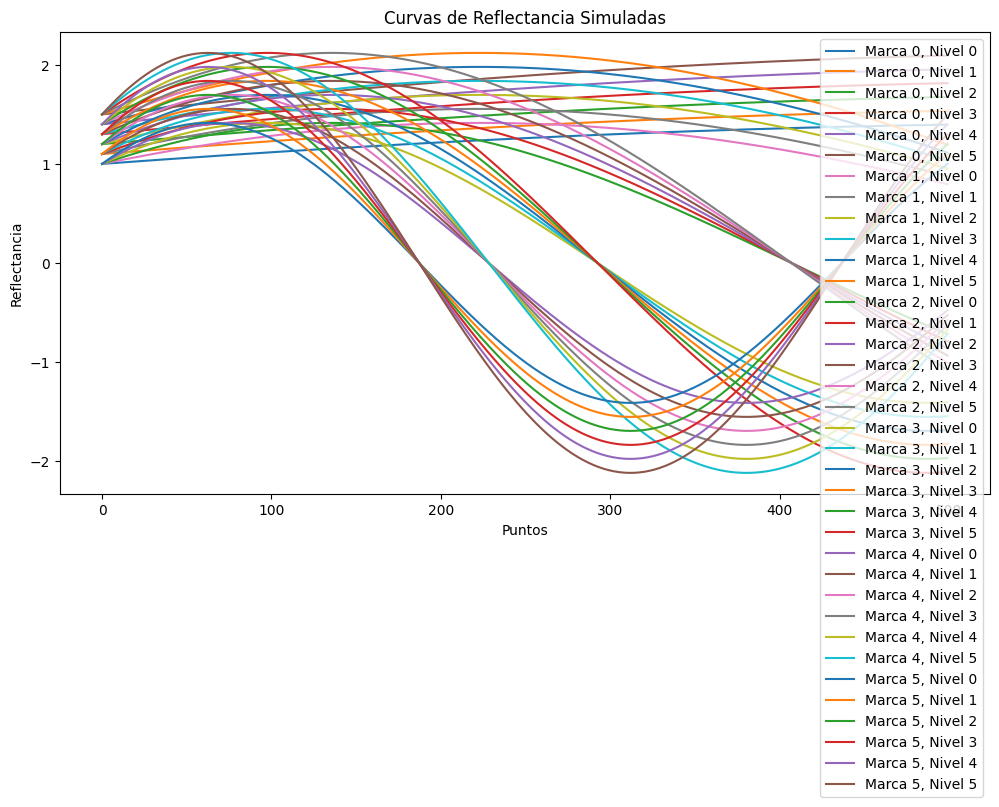

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

# Parámetros
num_marcas = 6
num_niveles = 6
num_puntos = 500
frecuencias = np.linspace(0.1, 1.0, num_marcas)  # Diferentes frecuencias para cada marca

# Generar datos
def generar_datos(frecuencia, nivel):
    t = np.linspace(0, 2 * np.pi, num_puntos)
    amplitud = 1 + nivel * 0.1
    curva = amplitud * (np.sin(frecuencia * t) + np.cos(frecuencia * t))
    return curva

X = []
y_marca = []
y_adulteracion = []

for marca in range(num_marcas):
    for nivel in range(num_niveles):
        curva = generar_datos(frecuencias[marca], nivel)
        X.append(curva)
        y_marca.append(marca)
        y_adulteracion.append(nivel)

X = np.array(X)
y_marca = np.array(y_marca)
y_adulteracion = np.array(y_adulteracion)

# Preprocesar datos
X = X.reshape((X.shape[0], X.shape[1]))  # Asegurarse de que X tenga la forma correcta para el autoencoder

# Autoencoder
input_dim = X.shape[1]
encoding_dim = 20  # Dimensión de codificación

input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='relu')(input_layer)
decoded = Dense(input_dim, activation='sigmoid')(encoded)

autoencoder = Model(inputs=input_layer, outputs=decoded)
encoder = Model(inputs=input_layer, outputs=encoded)

autoencoder.compile(optimizer=Adam(), loss='mean_squared_error')
autoencoder.fit(X, X, epochs=50, batch_size=8, validation_split=0.2)

# Codificación de datos
X_encoded = encoder.predict(X)

# Paso 1: Clasificación de Marca con KNN
X_train, X_test, y_marca_train, y_marca_test = train_test_split(X_encoded, y_marca, test_size=0.2, random_state=42)

# Crear y entrenar modelo KNN para la clasificación de marcas
knn_marca = KNeighborsClassifier(n_neighbors=3)
knn_marca.fit(X_train, y_marca_train)

# Evaluar el modelo
y_marca_pred = knn_marca.predict(X_test)
print(f"Accuracy de clasificación de marcas: {accuracy_score(y_marca_test, y_marca_pred):.2f}")

# Paso 2: Clasificación del Nivel de Adulteración con KNN

adulteracion_acc = []

for marca in range(num_marcas):
    # Filtrar los datos para la marca específica
    X_marca = X_encoded[y_marca == marca]
    y_adulteracion_marca = y_adulteracion[y_marca == marca]

    # Dividir el conjunto de datos
    X_train, X_test, y_train, y_test = train_test_split(X_marca, y_adulteracion_marca, test_size=0.2, random_state=42)

    # Crear y entrenar modelo KNN para la clasificación de adulteración
    knn_adulteracion = KNeighborsClassifier(n_neighbors=3)
    knn_adulteracion.fit(X_train, y_train)

    # Evaluar el modelo
    y_pred = knn_adulteracion.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    adulteracion_acc.append(acc)

    print(f"Accuracy de clasificación de adulteración para marca {marca}: {acc:.2f}")

# Ejemplo de predicción con el enfoque jerárquico
nueva_muestra = generar_datos(frecuencias[2], 3).reshape(1, -1)  # Nueva muestra
nueva_muestra_encoded = encoder.predict(nueva_muestra)  # Codificar nueva muestra

# Paso 1: Predecir la marca
predicted_marca = knn_marca.predict(nueva_muestra_encoded)
print(f"Predicción de la marca: {predicted_marca[0]}")

# Paso 2: Predecir el nivel de adulteración dentro de la marca
predicted_adulteracion_models = [KNeighborsClassifier(n_neighbors=3).fit(
    X_encoded[y_marca == marca],
    y_adulteracion[y_marca == marca]
) for marca in range(num_marcas)]

predicted_adulteracion = predicted_adulteracion_models[predicted_marca[0]].predict(nueva_muestra_encoded)
print(f"Predicción del nivel de adulteración: {predicted_adulteracion[0]}")

# Opcional: Visualizar algunas curvas de datos
plt.figure(figsize=(12, 6))
for marca in range(num_marcas):
    for nivel in range(num_niveles):
        curva = generar_datos(frecuencias[marca], nivel)
        plt.plot(curva, label=f'Marca {marca}, Nivel {nivel}')
plt.title('Curvas de Reflectancia Simuladas')
plt.xlabel('Puntos')
plt.ylabel('Reflectancia')
plt.legend()
plt.show()

In [20]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

# Parámetros
num_marcas = 6
num_niveles = 6
num_puntos = 500
frecuencias = np.linspace(0.1, 1.0, num_marcas)  # Diferentes frecuencias para cada marca

# Generar datos
def generar_datos(frecuencia, nivel):
    t = np.linspace(0, 2 * np.pi, num_puntos)
    amplitud = 1 + nivel * 0.1
    curva = amplitud * (np.sin(frecuencia * t) + np.cos(frecuencia * t))
    return curva

X = []
y_marca = []
y_adulteracion = []

for marca in range(num_marcas):
    for nivel in range(num_niveles):
        curva = generar_datos(frecuencias[marca], nivel)
        X.append(curva)
        y_marca.append(marca)
        y_adulteracion.append(nivel)

X = np.array(X)
y_marca = np.array(y_marca)
y_adulteracion = np.array(y_adulteracion)

# Calcular la matriz de similitud usando distancia de Wasserstein
def calcular_matriz_similitud(X):
    # Se usa cdist para calcular la distancia entre todas las muestras
    # Aquí se puede reemplazar con la distancia de Wasserstein si se tiene una implementación
    return cdist(X, X, metric='euclidean')

matriz_similitud = calcular_matriz_similitud(X)

# Convertir la matriz de similitud a un formato adecuado para KNN
def preparar_datos_knn(matriz_similitud, etiquetas):
    X_knn = matriz_similitud
    y_knn = etiquetas
    return X_knn, y_knn

# Paso 1: Clasificación de Marca
X_knn, y_marca_knn = preparar_datos_knn(matriz_similitud, y_marca)

X_train, X_test, y_marca_train, y_marca_test = train_test_split(X_knn, y_marca_knn, test_size=0.2, random_state=42)

# Crear y entrenar modelo KNN para la clasificación de marcas
knn_marca = KNeighborsClassifier(n_neighbors=3, metric='precomputed')
knn_marca.fit(X_train, y_marca_train)

# Evaluar el modelo
y_marca_pred = knn_marca.predict(X_test)
print(f"Accuracy de clasificación de marcas: {accuracy_score(y_marca_test, y_marca_pred):.2f}")

# Paso 2: Clasificación del Nivel de Adulteración con KNN

adulteracion_acc = []

for marca in range(num_marcas):
    # Filtrar los datos para la marca específica
    X_marca = matriz_similitud[y_marca == marca]
    y_adulteracion_marca = y_adulteracion[y_marca == marca]

    # Convertir matriz de similitud para KNN
    X_knn_marca, y_adulteracion_knn = preparar_datos_knn(X_marca, y_adulteracion_marca)

    # Dividir el conjunto de datos
    X_train, X_test, y_train, y_test = train_test_split(X_knn_marca, y_adulteracion_knn, test_size=0.2, random_state=42)

    # Crear y entrenar modelo KNN para la clasificación de adulteración
    knn_adulteracion = KNeighborsClassifier(n_neighbors=3, metric='precomputed')
    knn_adulteracion.fit(X_train, y_train)

    # Evaluar el modelo
    y_pred = knn_adulteracion.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    adulteracion_acc.append(acc)

    print(f"Accuracy de clasificación de adulteración para marca {marca}: {acc:.2f}")

# Ejemplo de predicción con el enfoque jerárquico
nueva_muestra = generar_datos(frecuencias[2], 3).reshape(1, -1)  # Nueva muestra
nueva_muestra_similitud = calcular_matriz_similitud(X, nueva_muestra).reshape(-1)  # Calcula la distancia a todas las muestras

# Paso 1: Predecir la marca
predicted_marca = knn_marca.predict([nueva_muestra_similitud])
print(f"Predicción de la marca: {predicted_marca[0]}")

# Paso 2: Predecir el nivel de adulteración dentro de la marca
X_marca = matriz_similitud[y_marca == predicted_marca[0]]
y_adulteracion_marca = y_adulteracion[y_marca == predicted_marca[0]]
knn_adulteracion = KNeighborsClassifier(n_neighbors=3, metric='precomputed')
knn_adulteracion.fit(X_marca, y_adulteracion_marca)

predicted_adulteracion = knn_adulteracion.predict([nueva_muestra_similitud])
print(f"Predicción del nivel de adulteración: {predicted_adulteracion[0]}")

# Opcional: Visualizar algunas curvas de datos
plt.figure(figsize=(12, 6))
for marca in range(num_marcas):
    for nivel in range(num_niveles):
        curva = generar_datos(frecuencias[marca], nivel)
        plt.plot(curva, label=f'Marca {marca}, Nivel {nivel}')
plt.title('Curvas de Reflectancia Simuladas')
plt.xlabel('Puntos')
plt.ylabel('Reflectancia')
plt.legend()
plt.show()

ValueError: Precomputed matrix must be square. Input is a 28x36 matrix.

In [21]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist

# Parámetros
num_marcas = 6
num_niveles = 6
num_puntos = 500
frecuencias = np.linspace(0.1, 1.0, num_marcas)  # Diferentes frecuencias para cada marca

# Generar datos
def generar_datos(frecuencia, nivel):
    t = np.linspace(0, 2 * np.pi, num_puntos)
    amplitud = 1 + nivel * 0.1
    curva = amplitud * (np.sin(frecuencia * t) + np.cos(frecuencia * t))
    return curva

X = []
y_marca = []
y_adulteracion = []

for marca in range(num_marcas):
    for nivel in range(num_niveles):
        curva = generar_datos(frecuencias[marca], nivel)
        X.append(curva)
        y_marca.append(marca)
        y_adulteracion.append(nivel)

X = np.array(X)
y_marca = np.array(y_marca)
y_adulteracion = np.array(y_adulteracion)

# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_marca_train, y_marca_test = train_test_split(X, y_marca, test_size=0.2, random_state=42)

# Crear la matriz de distancias
def crear_matriz_distancias(X):
    return cdist(X, X, metric='euclidean')

# Calcular la matriz de distancias para los datos de entrenamiento y prueba
X_train_distancias = crear_matriz_distancias(X_train)
X_test_distancias = crear_matriz_distancias(X_test)

# Crear y entrenar el modelo KNN para la clasificación de marcas usando distancias precomputadas
knn_marca = KNeighborsClassifier(n_neighbors=3, metric='precomputed')
knn_marca.fit(X_train_distancias, y_marca_train)

# Evaluar el modelo
X_test_distancias = cdist(X_test, X_train, metric='euclidean')  # Distancias entre test y train
y_marca_pred = knn_marca.predict(X_test_distancias)
print(f"Accuracy de clasificación de marcas: {accuracy_score(y_marca_test, y_marca_pred):.2f}")

# Paso 2: Clasificación del Nivel de Adulteración para cada marca
adulteracion_acc = []

for marca in range(num_marcas):
    # Filtrar los datos para la marca específica
    X_marca = X[y_marca == marca]
    y_adulteracion_marca = y_adulteracion[y_marca == marca]

    # Dividir el conjunto de datos
    X_train_marca, X_test_marca, y_train_marca, y_test_marca = train_test_split(X_marca, y_adulteracion_marca, test_size=0.2, random_state=42)

    # Crear la matriz de distancias
    X_train_distancias_marca = crear_matriz_distancias(X_train_marca)
    X_test_distancias_marca = cdist(X_test_marca, X_train_marca, metric='euclidean')

    # Crear y entrenar el modelo KNN para la clasificación de adulteración usando distancias precomputadas
    knn_adulteracion = KNeighborsClassifier(n_neighbors=3, metric='precomputed')
    knn_adulteracion.fit(X_train_distancias_marca, y_train_marca)

    # Evaluar el modelo
    y_adulteracion_pred = knn_adulteracion.predict(X_test_distancias_marca)
    acc = accuracy_score(y_test_marca, y_adulteracion_pred)
    adulteracion_acc.append(acc)

    print(f"Accuracy de clasificación de adulteración para marca {marca}: {acc:.2f}")

# Ejemplo de predicción con el enfoque jerárquico
nueva_muestra = generar_datos(frecuencias[2], 3).reshape(1, -1)  # Nueva muestra
nueva_muestra_distancia = cdist(nueva_muestra, X_train, metric='euclidean')  # Distancias entre nueva muestra y datos de entrenamiento

# Paso 1: Predecir la marca
predicted_marca = knn_marca.predict(nueva_muestra_distancia)
print(f"Predicción de la marca: {predicted_marca[0]}")

# Paso 2: Predecir el nivel de adulteración dentro de la marca
X_train_marca = X[y_marca == predicted_marca[0]]
y_train_adulteracion = y_adulteracion[y_marca == predicted_marca[0]]
X_train_distancias_marca = crear_matriz_distancias(X_train_marca)
nueva_muestra_distancia_marca = cdist(nueva_muestra, X_train_marca, metric='euclidean')

knn_adulteracion = KNeighborsClassifier(n_neighbors=3, metric='precomputed')
knn_adulteracion.fit(X_train_distancias_marca, y_train_adulteracion)
predicted_adulteracion = knn_adulteracion.predict(nueva_muestra_distancia_marca)
print(f"Predicción del nivel de adulteración: {predicted_adulteracion[0]}")

Accuracy de clasificación de marcas: 1.00
Accuracy de clasificación de adulteración para marca 0: 0.00
Accuracy de clasificación de adulteración para marca 1: 0.00
Accuracy de clasificación de adulteración para marca 2: 0.00
Accuracy de clasificación de adulteración para marca 3: 0.00
Accuracy de clasificación de adulteración para marca 4: 0.00
Accuracy de clasificación de adulteración para marca 5: 0.00
Predicción de la marca: 2
Predicción del nivel de adulteración: 2


In [22]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import ot  # Python Optimal Transport

# Parámetros
num_marcas = 6
num_niveles = 6
num_puntos = 500
frecuencias = np.linspace(0.1, 1.0, num_marcas)  # Diferentes frecuencias para cada marca

# Generar datos
def generar_datos(frecuencia, nivel):
    t = np.linspace(0, 2 * np.pi, num_puntos)
    amplitud = 1 + nivel * 0.1
    curva = amplitud * (np.sin(frecuencia * t) + np.cos(frecuencia * t))
    return curva

X = []
y_marca = []
y_adulteracion = []

for marca in range(num_marcas):
    for nivel in range(num_niveles):
        curva = generar_datos(frecuencias[marca], nivel)
        X.append(curva)
        y_marca.append(marca)
        y_adulteracion.append(nivel)

X = np.array(X)
y_marca = np.array(y_marca)
y_adulteracion = np.array(y_adulteracion)

# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_marca_train, y_marca_test = train_test_split(X, y_marca, test_size=0.2, random_state=42)

# Crear la matriz de distancias de Wasserstein
def crear_matriz_distancias_wasserstein(X):
    n = X.shape[0]
    distancias = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            distancias[i, j] = ot.dist(X[i], X[j], metric='wasserstein')
    return distancias

# Calcular la matriz de distancias para los datos de entrenamiento y prueba
X_train_distancias = crear_matriz_distancias_wasserstein(X_train)
X_test_distancias = np.zeros((X_test.shape[0], X_train.shape[0]))

for i in range(X_test.shape[0]):
    for j in range(X_train.shape[0]):
        X_test_distancias[i, j] = ot.dist(X_test[i], X_train[j], metric='wasserstein')

# Crear y entrenar el modelo KNN para la clasificación de marcas usando distancias precomputadas
knn_marca = KNeighborsClassifier(n_neighbors=3, metric='precomputed')
knn_marca.fit(X_train_distancias, y_marca_train)

# Evaluar el modelo
y_marca_pred = knn_marca.predict(X_test_distancias)
print(f"Accuracy de clasificación de marcas: {accuracy_score(y_marca_test, y_marca_pred):.2f}")

# Paso 2: Clasificación del Nivel de Adulteración para cada marca
adulteracion_acc = []

for marca in range(num_marcas):
    # Filtrar los datos para la marca específica
    X_marca = X[y_marca == marca]
    y_adulteracion_marca = y_adulteracion[y_marca == marca]

    # Dividir el conjunto de datos
    X_train_marca, X_test_marca, y_train_marca, y_test_marca = train_test_split(X_marca, y_adulteracion_marca, test_size=0.2, random_state=42)

    # Calcular la matriz de distancias de Wasserstein
    X_train_distancias_marca = crear_matriz_distancias_wasserstein(X_train_marca)
    X_test_distancias_marca = np.zeros((X_test_marca.shape[0], X_train_marca.shape[0]))

    for i in range(X_test_marca.shape[0]):
        for j in range(X_train_marca.shape[0]):
            X_test_distancias_marca[i, j] = ot.dist(X_test_marca[i], X_train_marca[j], metric='wasserstein')

    # Crear y entrenar el modelo KNN para la clasificación de adulteración usando distancias precomputadas
    knn_adulteracion = KNeighborsClassifier(n_neighbors=3, metric='precomputed')
    knn_adulteracion.fit(X_train_distancias_marca, y_train_marca)

    # Evaluar el modelo
    y_adulteracion_pred = knn_adulteracion.predict(X_test_distancias_marca)
    acc = accuracy_score(y_test_marca, y_adulteracion_pred)
    adulteracion_acc.append(acc)

    print(f"Accuracy de clasificación de adulteración para marca {marca}: {acc:.2f}")

# Ejemplo de predicción con el enfoque jerárquico
nueva_muestra = generar_datos(frecuencias[2], 3).reshape(1, -1)  # Nueva muestra
nueva_muestra_distancia = np.zeros((nueva_muestra.shape[0], X_train.shape[0]))

for i in range(nueva_muestra.shape[0]):
    for j in range(X_train.shape[0]):
        nueva_muestra_distancia[i, j] = ot.dist(nueva_muestra[i], X_train[j], metric='wasserstein')

# Paso 1: Predecir la marca
predicted_marca = knn_marca.predict(nueva_muestra_distancia)
print(f"Predicción de la marca: {predicted_marca[0]}")

# Paso 2: Predecir el nivel de adulteración dentro de la marca
X_train_marca = X[y_marca == predicted_marca[0]]
y_train_adulteracion = y_adulteracion[y_marca == predicted_marca[0]]
X_train_distancias_marca = crear_matriz_distancias_wasserstein(X_train_marca)
nueva_muestra_distancia_marca = np.zeros((nueva_muestra.shape[0], X_train_marca.shape[0]))

for i in range(nueva_muestra.shape[0]):
    for j in range(X_train_marca.shape[0]):
        nueva_muestra_distancia_marca[i, j] = ot.dist(nueva_muestra[i], X_train_marca[j], metric='wasserstein')

knn_adulteracion = KNeighborsClassifier(n_neighbors=3, metric='precomputed')
knn_adulteracion.fit(X_train_distancias_marca, y_train_adulteracion)
predicted_adulteracion = knn_adulteracion.predict(nueva_muestra_distancia_marca)
print(f"Predicción del nivel de adulteración: {predicted_adulteracion[0]}")

# Opcional: Visualizar algunas curvas de datos
plt.figure(figsize=(12, 6))
for marca in range(num_marcas):
    for nivel in range(num_niveles):
        curva = generar_datos(frecuencias[marca], nivel)
        plt.plot(curva, label=f'Marca {marca}, Nivel {nivel}')
plt.title('Curvas de Reflectancia Simuladas')
plt.xlabel('Puntos')
plt.ylabel('Reflectancia')
plt.legend()
plt.show()

ModuleNotFoundError: No module named 'ot'